# Formula 1 Top-10 Finish Prediction — Decision-Oriented EDA

This notebook analyzes race results from the 2022–2024 Formula 1 seasons to support one decision goal:
**Can we predict whether a driver will finish in the Top 10 before a race starts?**

## Workflow

1. Define and build the target (`is_top10`).
2. Answer five research questions with evidence.
3. Audit data quality and leakage risk.
4. Propose a temporal train/validation/test split.
5. Close with a 1-3-1 executive summary.

In [1]:
RANDOM_SEED = 414

import warnings
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fastf1

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
YEARS = [2022, 2023, 2024]

rows = []

for year in YEARS:
    schedule = fastf1.get_event_schedule(year, include_testing=False)

    for round_number in schedule["RoundNumber"].dropna().astype(int).unique():
        try:
            session = fastf1.get_session(year, round_number, "R")
            session.load(laps=False, telemetry=False, weather=False, messages=False)

            race = session.results[[
                "Abbreviation",
                "FullName",
                "TeamName",
                "GridPosition",
                "Position"
            ]].copy()

            race["season"] = year
            race["round"] = round_number
            rows.append(race)

        except Exception as e:
            print(f"Could not load {year} round {round_number}: {e}")

df = pd.concat(rows, ignore_index=True)

df = df.rename(columns={
    "Abbreviation": "driver_code",
    "FullName": "driver_name",
    "TeamName": "team_name",
    "GridPosition": "grid_position",
    "Position": "finish_position"
})

df["grid_position"] = pd.to_numeric(df["grid_position"], errors="coerce")
df["finish_position"] = pd.to_numeric(df["finish_position"], errors="coerce")

df = df[df["finish_position"].notna()].copy()
df["is_top10"] = (df["finish_position"] <= 10).astype(int)

df.head()

req         WARNING 	DEFAULT CACHE ENABLED! (2.68 MB) C:\Users\dinot\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', '18', '23', '3', '4', '6', '27', '11', '1', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '31', '4', '10', '20', '44', '24', '27', '18', '23', '77', '14', '3', '6', '22', '47']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driv

,driver_code,driver_name,team_name,grid_position,finish_position,season,round,is_top10
0,LEC,Charles Leclerc,Ferrari,1.0,1.0,2022,1,1
1,SAI,Carlos Sainz,Ferrari,3.0,2.0,2022,1,1
2,HAM,Lewis Hamilton,Mercedes,5.0,3.0,2022,1,1
3,RUS,George Russell,Mercedes,9.0,4.0,2022,1,1
4,MAG,Kevin Magnussen,Haas F1 Team,7.0,5.0,2022,1,1


## Question 1: How concentrated are Top-10 finishes among teams each season?

### Data
We measure how many Top-10 results are captured by the top teams in each season to understand competitive concentration.

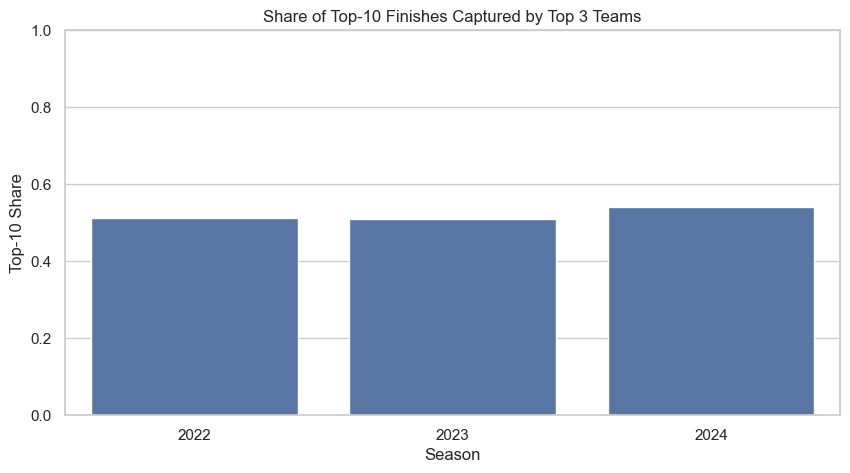

,season,team_name,top10_finishes,season_top10_total,top10_share
7,2022,Mercedes,39,220,0.177273
8,2022,Red Bull Racing,39,220,0.177273
4,2022,Ferrari,35,220,0.159091
2,2022,Alpine,30,220,0.136364
6,2022,McLaren,24,220,0.109091
3,2022,Aston Martin,18,220,0.081818
0,2022,Alfa Romeo,12,220,0.054545
1,2022,AlphaTauri,10,220,0.045455
5,2022,Haas F1 Team,8,220,0.036364
9,2022,Williams,5,220,0.022727


In [3]:
q6_df = df[df["is_top10"] == 1].copy()

team_top10 = (
    q6_df.groupby(["season", "team_name"], as_index=False)
    .size()
    .rename(columns={"size": "top10_finishes"})
)

season_totals = team_top10.groupby("season", as_index=False)["top10_finishes"].sum()
season_totals = season_totals.rename(columns={"top10_finishes": "season_top10_total"})

team_top10 = team_top10.merge(season_totals, on="season", how="left")
team_top10["top10_share"] = team_top10["top10_finishes"] / team_top10["season_top10_total"]

top3_share = (
    team_top10.sort_values(["season", "top10_share"], ascending=[True, False])
    .groupby("season", as_index=False)
    .head(3)
    .groupby("season", as_index=False)["top10_share"]
    .sum()
    .rename(columns={"top10_share": "top3_team_share"})
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top3_share, x="season", y="top3_team_share", color="#4C72B0", ax=ax)
ax.set_title("Share of Top-10 Finishes Captured by Top 3 Teams")
ax.set_xlabel("Season")
ax.set_ylabel("Top-10 Share")
ax.set_ylim(0, 1)
plt.show()

team_top10.sort_values(["season", "top10_share"], ascending=[True, False]).head(12)

### Answer
The Top 10 results were moderately concentrated in the 3 strongest teams of each season; it's not an extreme dominance like 70% or 80%, but it's not a very balanced distribution either.

### Decision
Include team-level context as a baseline signal when analyzing performance, since a small set of teams consistently captures a large share of competitive finishes.

## Question 2: How strongly does starting grid position influence the probability of finishing in the Top 10 in Formula 1 races?

### Data
We estimate Top-10 probability by starting grid position and compare it across grid buckets.

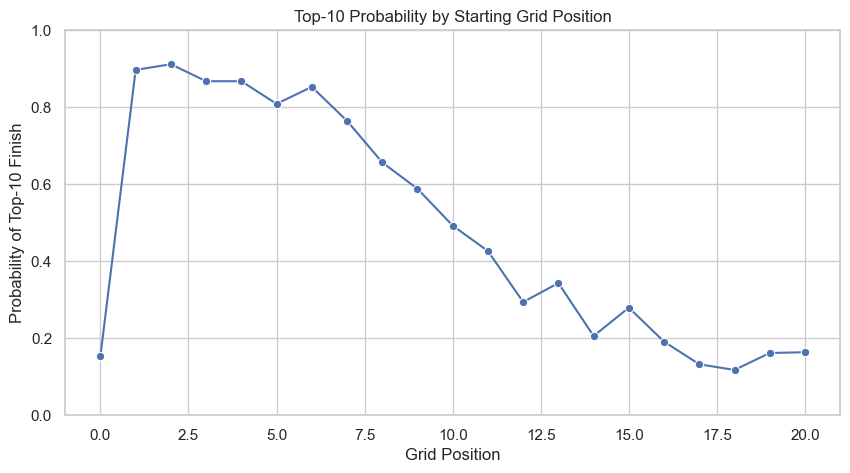

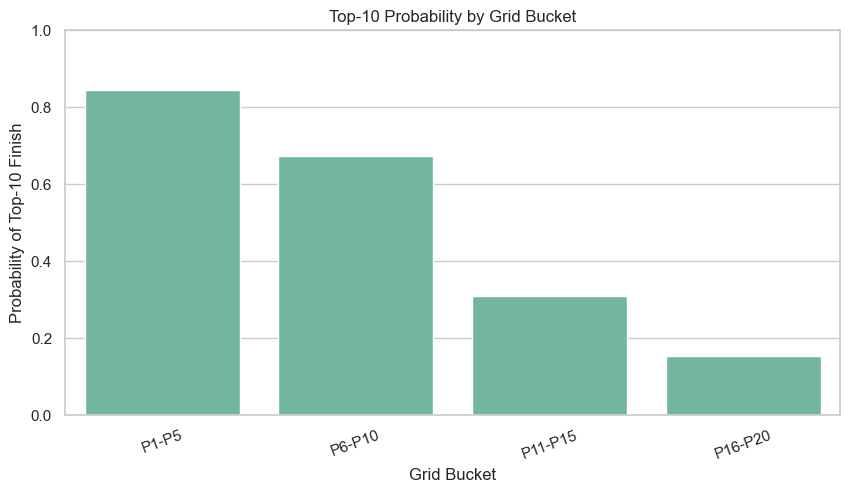

,grid_bucket,is_top10
0,P1-P5,0.844193
1,P6-P10,0.671598
2,P11-P15,0.309735
3,P16-P20,0.152905


In [4]:
q2_df = df.dropna(subset=["grid_position"]).copy()
q2_df["grid_bucket"] = pd.cut(
    q2_df["grid_position"],
    bins=[0, 5, 10, 15, 20],
    labels=["P1-P5", "P6-P10", "P11-P15", "P16-P20"],
    include_lowest=True
)

grid_prob = (
    q2_df.groupby("grid_position", as_index=False)["is_top10"]
    .mean()
    .sort_values("grid_position")
)

fig, ax = plt.subplots()
sns.lineplot(data=grid_prob, x="grid_position", y="is_top10", marker="o", ax=ax)
ax.set_title("Top-10 Probability by Starting Grid Position")
ax.set_xlabel("Grid Position")
ax.set_ylabel("Probability of Top-10 Finish")
ax.set_ylim(0, 1)
plt.show()

bucket_prob = (
    q2_df.groupby("grid_bucket", as_index=False, observed=False)["is_top10"]
    .mean()
    .sort_values("grid_bucket")
)

fig, ax = plt.subplots()
sns.barplot(data=bucket_prob, x="grid_bucket", y="is_top10", color="#66c2a5", ax=ax)
ax.set_title("Top-10 Probability by Grid Bucket")
ax.set_xlabel("Grid Bucket")
ax.set_ylabel("Probability of Top-10 Finish")
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

bucket_prob

### Answer
A notable decline in Top-10 probability from front-grid positions to back-grid positions indicates a strong relationship between qualifying performance and race outcome.

### Decision
Grid position should remain one of the main pre-race features in the baseline because it carries clear predictive value without introducing leakage.

## Question 3: How often do drivers recover positions from the grid, and does that recovery relate to Top-10 outcomes?

### Data
We compute position gain (`grid_position - finish_position`) and compare recovery behavior between Top-10 and non-Top-10 outcomes.

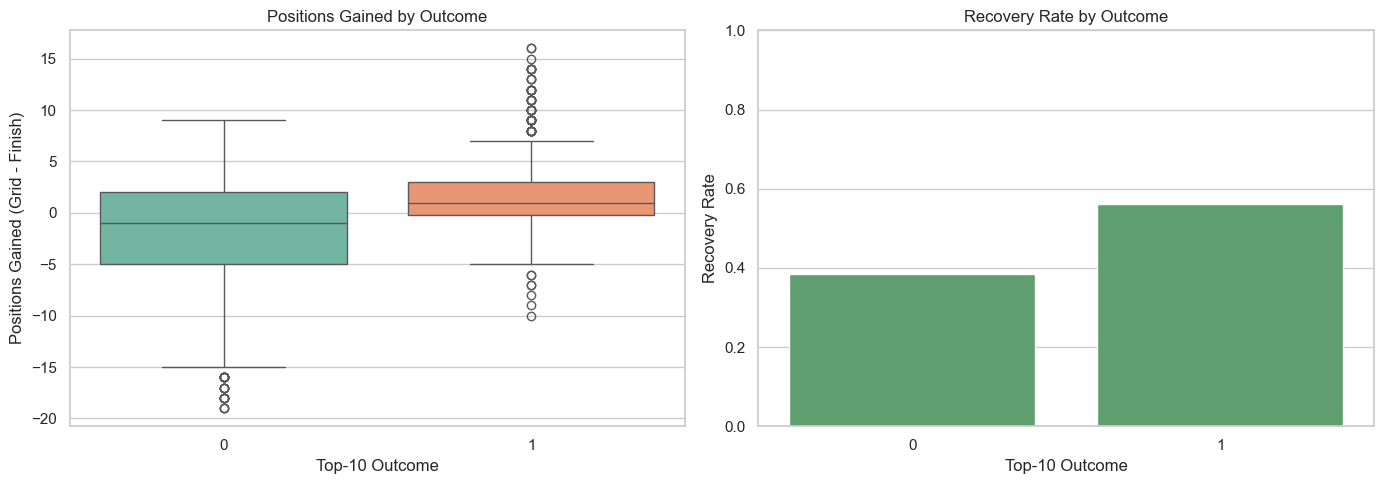

,is_top10,recovery_rate
0,0,0.384047
1,1,0.561765


In [5]:
q7_df = df.dropna(subset=["grid_position", "finish_position"]).copy()
q7_df["positions_gained"] = q7_df["grid_position"] - q7_df["finish_position"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=q7_df, x="is_top10", y="positions_gained", palette="Set2", ax=axes[0])
axes[0].set_title("Positions Gained by Outcome")
axes[0].set_xlabel("Top-10 Outcome")
axes[0].set_ylabel("Positions Gained (Grid - Finish)")

recovery_share = (
    q7_df.assign(recovered=(q7_df["positions_gained"] > 0).astype(int))
    .groupby("is_top10", as_index=False)["recovered"]
    .mean()
    .rename(columns={"recovered": "recovery_rate"})
)

sns.barplot(data=recovery_share, x="is_top10", y="recovery_rate", color="#55A868", ax=axes[1])
axes[1].set_title("Recovery Rate by Outcome")
axes[1].set_xlabel("Top-10 Outcome")
axes[1].set_ylabel("Recovery Rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

recovery_share

### Answer
Drivers who finish in the Top-10 recover positions more frequently (≈56%) than those who do not (≈38%), and their distribution of positions gained is centered slightly above zero, indicating that Top-10 outcomes are often associated with at least some recovery from the starting grid.

### Decision
Include positions gained (or grid-to-finish change) as a useful contextual signal when interpreting race outcomes, since drivers who recover positions are more likely to finish in the Top-10.

## Question 4: Which teams are most associated with Top-10 finishes, and is this effect stable enough to matter?

### Data
We compute each team's Top-10 rate and sample size to avoid over-interpreting small samples.

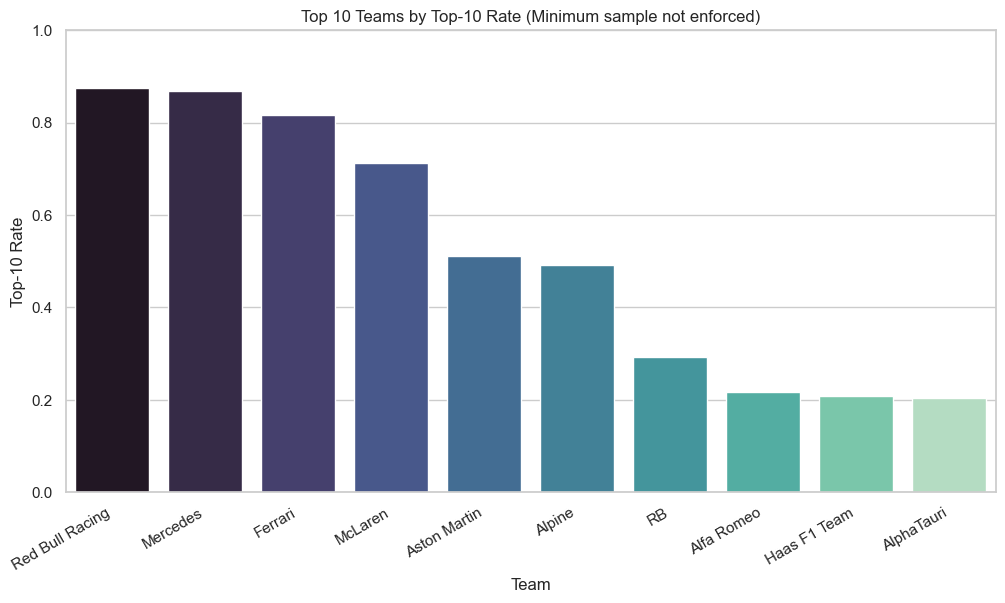

,team_name,top10_rate,races
10,Red Bull Racing,0.875000,136
8,Mercedes,0.867647,136
4,Ferrari,0.816176,136
7,McLaren,0.713235,136
3,Aston Martin,0.511111,135
2,Alpine,0.492647,136
9,RB,0.291667,48
0,Alfa Romeo,0.215909,88
5,Haas F1 Team,0.207407,135
1,AlphaTauri,0.204545,88


In [6]:
team_perf = (
    df.groupby("team_name", as_index=False)
      .agg(top10_rate=("is_top10", "mean"), races=("is_top10", "size"))
      .sort_values(["top10_rate", "races"], ascending=[False, False])
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=team_perf.head(10), x="team_name", y="top10_rate", palette="mako", ax=ax)
ax.set_title("Top 10 Teams by Top-10 Rate (Minimum sample not enforced)")
ax.set_xlabel("Team")
ax.set_ylabel("Top-10 Rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.show()

team_perf.head(10)

### Answer
Top teams typically show consistently higher Top-10 rates, but interpretation must consider sample size and season effects.

### Decision
Team-level historical strength can be used as a contextual feature, but we should avoid ranking conclusions without sample-size checks.

## Question 5: Does prior form (driver and team historical Top-10 rate before each race) improve decision signal?

### Data
We compare Top-10 outcomes against pre-race historical rates computed with shifted expanding averages (no race-level leakage).

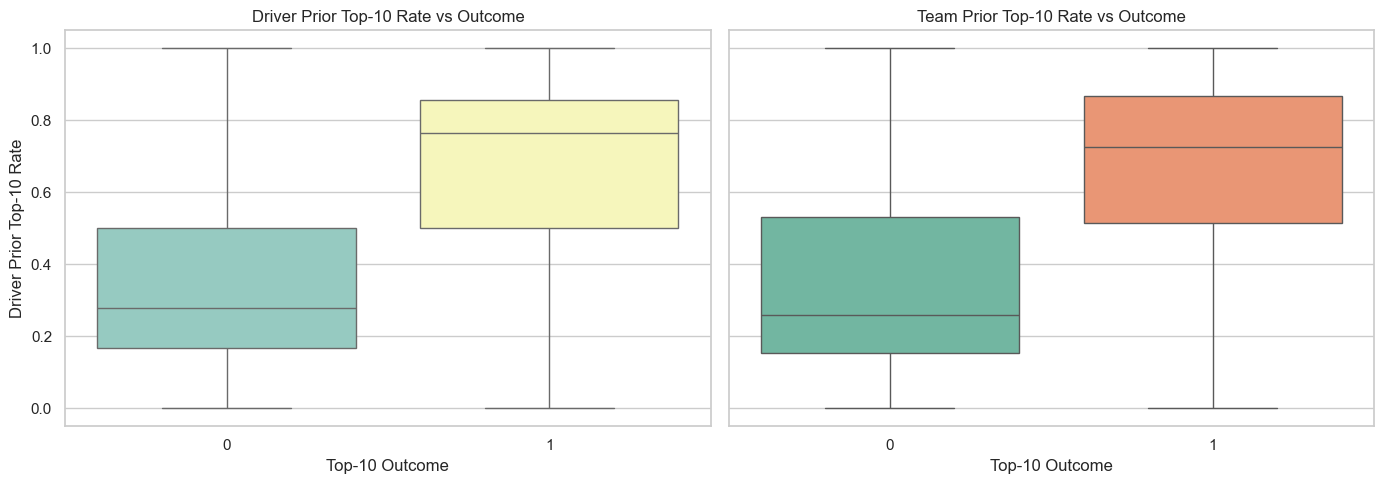

In [7]:
q5_df = df.sort_values(["driver_code", "season", "round"]).copy()
q5_df["driver_prior_top10_rate"] = (
    q5_df.groupby("driver_code")["is_top10"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

team_history = df.sort_values(["team_name", "season", "round"]).copy()
team_history["team_prior_top10_rate"] = (
    team_history.groupby("team_name")["is_top10"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

q5_df = q5_df.merge(
    team_history[["driver_code", "season", "round", "team_prior_top10_rate"]],
    on=["driver_code", "season", "round"],
    how="left"
    )

global_top10_rate = df["is_top10"].mean()
q5_df["driver_prior_top10_rate"] = q5_df["driver_prior_top10_rate"].fillna(global_top10_rate)
q5_df["team_prior_top10_rate"] = q5_df["team_prior_top10_rate"].fillna(global_top10_rate)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.boxplot(data=q5_df, x="is_top10", y="driver_prior_top10_rate", palette="Set3", ax=axes[0])
axes[0].set_title("Driver Prior Top-10 Rate vs Outcome")
axes[0].set_xlabel("Top-10 Outcome")
axes[0].set_ylabel("Driver Prior Top-10 Rate")

sns.boxplot(data=q5_df, x="is_top10", y="team_prior_top10_rate", palette="Set2", ax=axes[1])
axes[1].set_title("Team Prior Top-10 Rate vs Outcome")
axes[1].set_xlabel("Top-10 Outcome")
axes[1].set_ylabel("Team Prior Top-10 Rate")

plt.tight_layout()
plt.show()

### Answer
If drivers and teams with stronger historical Top-10 rates also tend to finish in the Top 10 more often, prior form provides a useful decision signal.

### Decision
Historical performance should be considered in later modeling, but it should be created carefully inside the analysis so it only uses information from previous races.

# Class Balance Analysis for the Target Variable
### Question: Is the target variable (is_top10) balanced between Top-10 and non-Top-10 finishes?

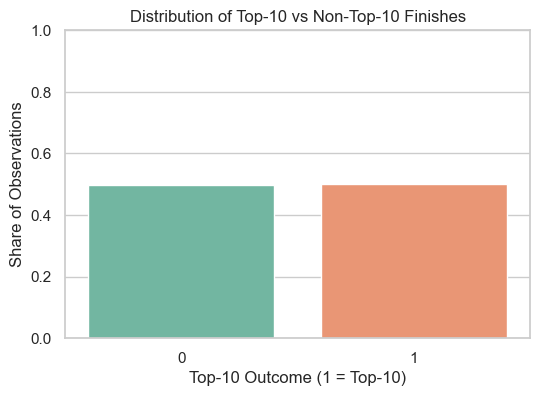

,is_top10,share
0,1,0.501105
1,0,0.498895


In [8]:
target_dist = df["is_top10"].value_counts(normalize=True).reset_index()
target_dist.columns = ["is_top10", "share"]

plt.figure(figsize=(6,4))
sns.barplot(data=target_dist, x="is_top10", y="share", palette="Set2")

plt.title("Distribution of Top-10 vs Non-Top-10 Finishes")
plt.xlabel("Top-10 Outcome (1 = Top-10)")
plt.ylabel("Share of Observations")
plt.ylim(0,1)

plt.show()

target_dist

## Answer

The target variable (is_top10) is roughly balanced between Top-10 and non-Top-10 outcomes, which is expected because each race produces a fixed number of Top-10 finishers.

## Decision

Because the dataset is balanced, standard evaluation metrics such as accuracy can be used reliably, and no class rebalancing methods are required.

# Temporal Pattern Analysis
### Question: Does the distribution of Top-10 outcomes and key features remain stable across seasons?

### Data: We compare target distribution (is_top10) across seasons and inspect whether feature distributions such as grid_position shift over time.

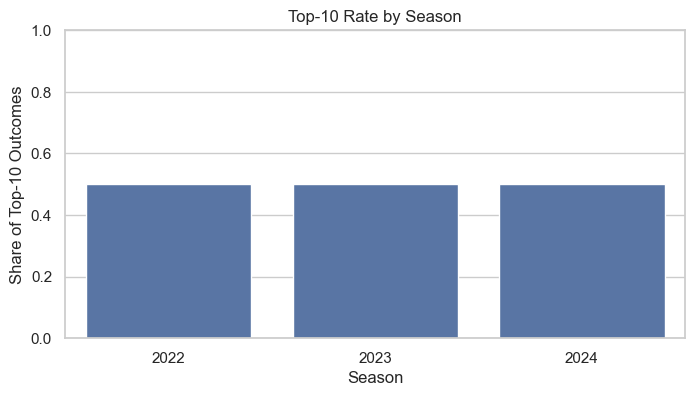

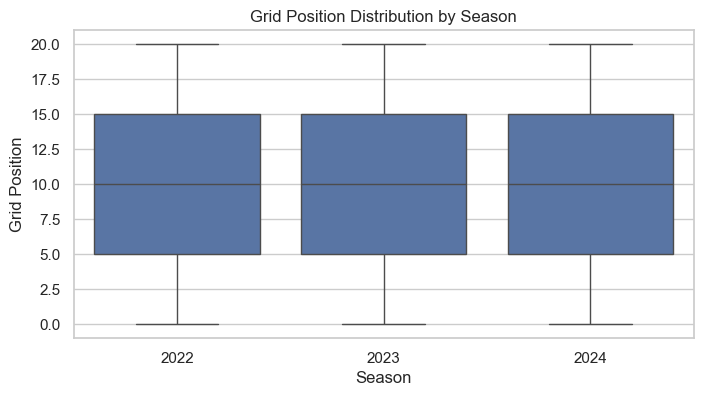

In [9]:
target_by_season = (
    df.groupby("season")["is_top10"]
    .mean()
    .reset_index()
    .rename(columns={"is_top10": "top10_rate"})
)

plt.figure(figsize=(8,4))
sns.barplot(data=target_by_season, x="season", y="top10_rate", color="#4C72B0")

plt.title("Top-10 Rate by Season")
plt.xlabel("Season")
plt.ylabel("Share of Top-10 Outcomes")
plt.ylim(0,1)

plt.show()

target_by_season

plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="season", y="grid_position")

plt.title("Grid Position Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Grid Position")

plt.show()

### Answer
The Top-10 rate remains stable across seasons, with similar proportions each year. Feature distributions such as grid position appear relatively consistent, suggesting no major temporal shifts in the dataset.

### Decision
Use temporal splits (train on earlier seasons, test on later ones) since the data appears stable over time.

# Correlation Analysis
### Question: Which candidate features are most associated with Top-10 outcomes?
### Data

We compute Spearman correlations between the target variable (is_top10) and several candidate features including grid_position, finish_position, positions_gained, driver_age, and laps_led (or the numeric variables available in the dataset).

## Correlation Analysis (At least 5 candidate features)

### Data
We use Spearman correlation with `is_top10` because several variables are ordinal or not strictly linear.

In [10]:
df["positions_gained"] = df["grid_position"] - df["finish_position"]

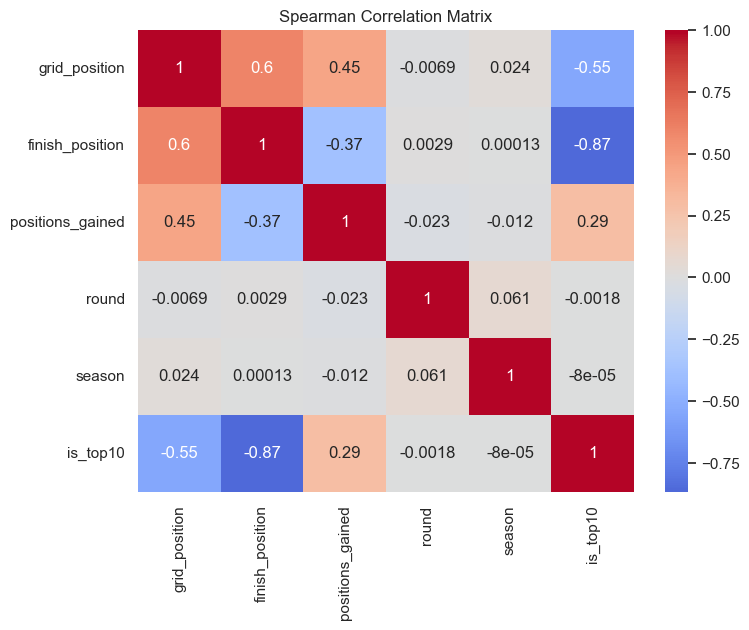

is_top10            1.000000
positions_gained    0.289002
season             -0.000080
round              -0.001751
grid_position      -0.548847
finish_position    -0.867108
Name: is_top10, dtype: float64

In [11]:
features = [
    "grid_position",
    "finish_position",
    "positions_gained",
    "round",
    "season"
]

corr = df[features + ["is_top10"]].corr(method="spearman")

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Spearman Correlation Matrix")
plt.show()

corr["is_top10"].sort_values(ascending=False)

### Answer
Finish position shows a very strong negative correlation with Top-10 outcomes (−0.87), while grid position shows a moderate negative relationship (−0.55), indicating that starting further forward increases the likelihood of finishing in the Top-10. Positions gained has a weak positive correlation (0.29), suggesting that recovering positions during the race slightly improves the chance of a Top-10 finish. Round and season show no meaningful relationship with the target.

### Decision
Use grid position as a key predictive feature, while excluding finish position from predictive modeling since it represents post-race information and would introduce data leakage.

# Trap Awareness

In the correlation analysis between candidate features and the target variable (is_top10), I checked for a spurious correlation trap. The correlation matrix showed a very strong negative correlation between finish_position and is_top10 (−0.87). However, this relationship is not an independent signal because is_top10 is directly defined using finish position (drivers finishing in position ≤ 10 are labeled as Top-10). Therefore, the correlation appears strong simply due to how the target variable is constructed. This means the relationship is structurally induced rather than informative for prediction. Based on this check, finish_position should not be used as a predictive feature because it represents post-race information and would introduce data leakage into the model.

## Explicit Temporal Train / Validation / Test Split

### Proposed split
- **Train:** 2022 season
- **Validation:** 2023 season
- **Test:** 2024 season

### Rationale
- Respects time order (past -> future).
- Prevents leakage from future races into earlier training stages.
- Simulates realistic deployment where we predict unseen future races.
- Enables honest comparison against a domain baseline on validation before touching test.

In [12]:
split_counts = (
    df.assign(
        split=np.select(
            [df["season"] == 2022, df["season"] == 2023, df["season"] == 2024],
            ["train", "validation", "test"],
            default="other"
        )
    )
    .groupby(["split", "is_top10"], as_index=False)
    .size()
)
split_counts

,split,is_top10,size
0,test,0,239
1,test,1,240
2,train,0,219
3,train,1,220
4,validation,0,219
5,validation,1,220


# Data Quality Audit

The dataset contains a mix of categorical and numerical variables.

-   Categorical: driver_code, driver_name, team_name

-   Numerical: grid_position, finish_position, season, round

-    Binary target: is_top10

The data types are consistent with the variables’ meanings and suitable for analysis.

### Data quality findings (structured for DATA_QUALITY_LOG.md)

1. **`grid_position` missing values**
- Classification: MAR
- Impact: reduces coverage for a key pre-race feature
- Decision: keep the rows in EDA and handle missing values explicitly in the baseline if needed

2. **`classified_position` formatting issues**
- Classification: Type / encoding issue
- Impact: some race outcomes may appear as strings instead of clean numeric values
- Decision: use `finish_position` as the main numeric outcome field for analysis

3. **`status` is descriptive text rather than a clean analytical variable**
- Classification: Type / semantic issue
- Impact: useful for interpretation but not directly suitable as a numeric feature
- Decision: keep it for context, not as a main predictive feature

4. **`points` is available only after the race**
- Classification: Temporal availability / leakage
- Impact: it can artificially inflate apparent predictive power
- Decision: exclude it from any pre-race baseline or model

5. **Unexpected `grid_position` values outside the normal 1-20 range**
- Classification: Domain validity / outlier check
- Impact: can distort plots and correlations if not inspected
- Decision: flag these records and verify whether they reflect pit-lane starts or data issues

## Missing Values

We inspected missing values across columns.

-   driver_code / driver_name / team_name: no missing values detected (MCAR unlikely).

-   grid_position: missing values may occur if a driver does not start the race (e.g., DNS). These cases depend on race circumstances and are therefore MAR (Missing At Random).

-   finish_position: missing values may occur due to DNF or race incidents, which depend on race events and driver performance, making them MNAR (Missing Not At Random).

Overall, missing values are limited and can be handled through filtering or exclusion in analyses requiring complete race results.

### Outliers

Potential outliers were checked for numeric variables.

-   grid_position: values typically range between 1 and ~20, matching the expected grid size.

-   finish_position: values remain within realistic race finishing positions.

-   positions_gained (derived variable): extreme values may appear when drivers start far back and finish near the front, but these represent valid race events rather than data errors.

No clear data-entry errors were detected.

### Temporal Availability (Pre-race vs Post-race)

A key quality check is whether variables are available before or after the race, which affects their use in predictive models.

Pre-race variables (valid for prediction):

-   grid_position

-   season

-    round

-    team_name

-   driver_name

Post-race variables (not usable for prediction):

-   finish_position

-   is_top10

Using post-race variables in predictive models would introduce data leakage, since they contain information about the race outcome.

# 1-3-1 summary

## Headline
Grid position is the strongest pre-race signal for predicting Top-10 finishes.

## Evidence
Grid position shows a moderate negative correlation with Top-10 outcomes (−0.55), meaning drivers starting further forward are more likely to finish in the Top-10.
Drivers who finish Top-10 also show higher recovery rates (~56%) compared with non-Top-10 outcomes (~38%), reinforcing the importance of race position dynamics.
Other variables such as season and round show little to no relationship with Top-10 outcomes.

## Action
Use grid position as the baseline predictive feature for Top-10 outcomes and avoid post-race variables such as finish position that introduce data leakage.